# PAYG with Contribution-Based Benefits

The pension benefit is now partly earnings-related.

$$\text{pen}(w,\ell) = \underbrace{\tau w\ell(1+n-\theta)}_{\text{minimum pension}} + \underbrace{\theta\cdot\tau w\ell}_{\text{earnings-related}}$$

| $\theta$ | Pension type | Labour distortion |
|---|---|---|
| 0 | Flat lump-sum | Maximum |
| 0.5 | Mixed (this model) | Intermediate |
| 1 | Fully earnings-related | Zero |

**Workflow:**
1. Calibrate $\nu_0$ and solve the no-pension reference steady state
2. Solve the 7-equation PAYG steady state at $\tau=0.3$, $\theta=0.5$
3. Compare across steady states and compute welfare (CEV)
4. Sweep $\theta \in [0,1]$ (fixed $\tau=0.3$): how does earnings-linkage affect outcomes?
5. Sweep $\tau \in [0,0.5]$ (fixed $\theta=0.5$): how does contribution rate affect outcomes?

## Cell 1 — Imports and parameters

In [39]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

In [41]:
import os

# define your output folder
output_dir = r"C:\Users\russale86005\Dropbox\TEACHING\Advanced Macro Fiscal Policies\New_Course_OLG_2026\Lectures\02_pensions_and_public_debt\code\Python\Output"
os.makedirs(output_dir, exist_ok=True)

In [43]:
# ── Structural parameters ─────────────────────────────────────────────────
alpha = 0.36    # capital share (BEA NIPA)
beta0 = 0.40    # discount factor (one model period ≈ 30 years)
n     = 0.10    # population growth rate
nu1   = 3.33    # Frisch elasticity = 1/nu1 ≈ 0.30

# ── Baseline PAYG parameters ──────────────────────────────────────────────
tau_base   = 0.30   # contribution rate
theta_base = 0.50   # earnings-linkage parameter

print('Parameters OK.')

Parameters OK.


## Cell 2 — Factor prices and nu0 calibration

$\nu_0$ is calibrated so that optimal labour $= 0.30$ at the no-pension steady state.
The analytical formula comes from inverting the static labour FOC at $\tau=0$:
$$\nu_0 = \frac{w_{ss}}{\ell_{ss}^{\nu_1}\,c_1^{ss}}$$

In [46]:
def interest(k, l): return alpha*k**(alpha-1)*l**(1-alpha)
def wage(k, l):     return (1-alpha)*k**alpha*l**(-alpha)

# Calibrate nu0 analytically at tau=0
l_target = 0.30
kss_ref  = (beta0/(1+beta0) * (1-alpha)/(1+n))**(1/(1-alpha)) * l_target
wss_ref  = wage(kss_ref, l_target)
c1ss_ref = 1/(1+beta0) * wss_ref * l_target
nu0      = wss_ref / (l_target**nu1 * c1ss_ref)

print(f'nu0    = {nu0:.4f}')
print(f'k_ref  = {kss_ref:.4f}')
print(f'w_ref  = {wss_ref:.4f}')
print(f'c1_ref = {c1ss_ref:.4f}')
print(f'Frisch elasticity = 1/nu1 = {1/nu1:.3f}')

nu0    = 257.1538
k_ref  = 0.0182
w_ref  = 0.2333
c1_ref = 0.0500
Frisch elasticity = 1/nu1 = 0.300


## Cell 3 — The 7-equation steady-state system

The steady state solves jointly for $(k,\ell,w,r,c_1,c_2,\text{pen}^{\min})$:

| # | Equation | Meaning |
|---|---|---|
| 1 | $\text{pen}^{\min} = \tau w\ell(1+n-\theta)$ | Minimum pension definition |
| 2 | $w = (1-\alpha)k^\alpha\ell^{-\alpha}$ | Competitive wage |
| 3 | $r = \alpha k^{\alpha-1}\ell^{1-\alpha}$ | Competitive interest rate |
| 4 | $\nu_0\ell^{\nu_1}c_1 = (1-\tau)w + \frac{\theta\tau w}{1+r}$ | Labour FOC |
| 5 | $\beta_0(1+r)c_1 = c_2$ | Euler equation |
| 6 | $(1-\tau)w\ell + \frac{\text{pen}^{\min}+\theta\tau w\ell}{1+r} = c_1 + \frac{c_2}{1+r}$ | Lifetime budget |
| 7 | $(1+n)k = (1-\tau)w\ell - c_1$ | Capital market clearing |

**Key:** The right-hand side now has an extra term
$\frac{\theta\tau w}{1+r}$: the present value of the extra pension earned by working
one more unit. This reduces the effective tax on labour.

In [49]:
def steadystate(x, tau, theta):
    """
    7-equation residual system for the steady state.
    Unknowns: x = [k, l, w, r, c1, c2, penmin]
    Returns residuals; all equal zero at equilibrium.
    """
    k, l, w, r, c1, c2, penmin = x
    if k<=0 or l<=0 or c1<=0 or c2<=0: return [1e10]*7

    y = [0.0]*7
    # Eq 1: minimum pension
    y[0] = penmin - tau*w*l*(1+n-theta)
    # Eq 2: competitive wage
    y[1] = w - wage(k, l)
    # Eq 3: competitive interest rate
    y[2] = r - interest(k, l)
    # Eq 4: labour FOC — net wage = disutility, adjusted for pension linkage
    y[3] = nu0*l**nu1*c1 - (1-tau)*w - theta*tau*w/(1+r)
    # Eq 5: Euler equation
    y[4] = beta0*(1+r)*c1 - c2
    # Eq 6: lifetime budget constraint
    y[5] = ((1-tau)*w*l + (penmin + theta*tau*w*l)/(1+r)
            - c1 - c2/(1+r))
    # Eq 7: capital market clearing
    y[6] = (1+n)*k - (1-tau)*w*l + c1
    return y

def compute_ss(tau, theta, x0=None):
    """Solve the 7-equation system and return a results dict."""
    if x0 is None:
        x0 = [0.018, 0.30, 0.233, 2.17, 0.050, 0.063, 0.010]
    x = fsolve(lambda v: steadystate(v, tau, theta), x0)
    k, l, w, r, c1, c2, penmin = x
    y   = k**alpha * l**(1-alpha)
    pen = penmin + theta*tau*w*l        # total pension = min + earnings-related
    U   = np.log(c1) + beta0*np.log(c2) - nu0*l**(1+nu1)/(1+nu1)
    return dict(k=k, l=l, w=w, r=r, c1=c1, c2=c2,
                penmin=penmin, pen=pen, y=y, U=U,
                tau=tau, theta=theta)

print('steadystate and compute_ss defined.')

steadystate and compute_ss defined.


## Cell 4 — Compute reference and baseline steady states

In [52]:
# Reference: no pension (tau=0)
ss_ref  = compute_ss(0.0, theta_base)

# Baseline: tau=0.3, theta=0.5
ss_base = compute_ss(tau_base, theta_base)

def cev(U, U_ref=ss_ref['U']):
    """CEV relative to no-pension reference."""
    return np.exp((U - U_ref)/(1+beta0)) - 1

print('REFERENCE (tau=0, theta=0.5):')
print(f'  k={ss_ref["k"]:.4f}  l={ss_ref["l"]:.4f}  y={ss_ref["y"]:.4f}')
print(f'  w={ss_ref["w"]:.4f}  r={ss_ref["r"]:.2f}%  U={ss_ref["U"]:.4f}')
print()
print('BASELINE (tau=0.3, theta=0.5):')
print(f'  k={ss_base["k"]:.4f}  l={ss_base["l"]:.4f}  y={ss_base["y"]:.4f}')
print(f'  w={ss_base["w"]:.4f}  r={ss_base["r"]:.2f}%  U={ss_base["U"]:.4f}')
print(f'  penmin={ss_base["penmin"]:.4f}  pen(total)={ss_base["pen"]:.4f}')
print()
print(f'CEV (tau=0.3 vs tau=0) = {cev(ss_base["U"])*100:.2f}%')
print()
print('Interpretation: contribution-based design (theta=0.5) is less distortionary')
print('than flat lump-sum (theta=0, Ch.6.3.2 gives CEV=-38.4%) because')
print('part of the contribution comes back as earnings-related pension.')

REFERENCE (tau=0, theta=0.5):
  k=0.0182  l=0.3000  y=0.1093
  w=0.2333  r=2.17%  U=-4.4234

BASELINE (tau=0.3, theta=0.5):
  k=0.0068  l=0.2967  y=0.0762
  w=0.1643  r=4.04%  U=-5.1027
  penmin=0.0088  pen(total)=0.0161

CEV (tau=0.3 vs tau=0) = -38.44%

Interpretation: contribution-based design (theta=0.5) is less distortionary
than flat lump-sum (theta=0 gives CEV=-38.4%) because
part of the contribution comes back as earnings-related pension.


## Cell 5 — Sweep over $\theta$ (earnings-linkage)

Fix $\tau=0.3$ and vary $\theta$ from 0 (flat lump-sum) to 1 (fully actuarially fair).
This traces out how increasing earnings-linkage reduces distortions.

In [55]:
thetas = np.linspace(0.0, 1.0, 41)
res_theta = []
x0 = None
for th in thetas:
    ss = compute_ss(tau_base, th, x0)
    res_theta.append(ss)
    x0 = [ss['k'], ss['l'], ss['w'], ss['r'], ss['c1'], ss['c2'], ss['penmin']]

print(f'theta=0.0: k={res_theta[0]["k"]:.4f}  l={res_theta[0]["l"]:.4f}  CEV={cev(res_theta[0]["U"])*100:.2f}%')
print(f'theta=0.5: k={res_theta[20]["k"]:.4f}  l={res_theta[20]["l"]:.4f}  CEV={cev(res_theta[20]["U"])*100:.2f}%')
print(f'theta=1.0: k={res_theta[-1]["k"]:.4f}  l={res_theta[-1]["l"]:.4f}  CEV={cev(res_theta[-1]["U"])*100:.2f}%')

theta=0.0: k=0.0067  l=0.2939  CEV=-38.48%
theta=0.5: k=0.0068  l=0.2967  CEV=-38.44%
theta=1.0: k=0.0069  l=0.2995  CEV=-38.43%


## Cell 6 — Sweep over $\tau$ (contribution rate)

Fix $\theta=0.5$ and vary $\tau$ from 0 to 0.5.
This shows how increasing the contribution rate affects capital, labour, and welfare.

In [58]:
taus = np.linspace(0.0, 0.50, 51)
res_tau = []
x0 = None
for ta in taus:
    ss = compute_ss(ta, theta_base, x0)
    res_tau.append(ss)
    x0 = [ss['k'], ss['l'], ss['w'], ss['r'], ss['c1'], ss['c2'], ss['penmin']]

print(f'tau=0.0 : k={res_tau[0]["k"]:.4f}  l={res_tau[0]["l"]:.4f}  CEV={cev(res_tau[0]["U"])*100:.2f}%')
print(f'tau=0.3 : k={res_tau[30]["k"]:.4f}  l={res_tau[30]["l"]:.4f}  CEV={cev(res_tau[30]["U"])*100:.2f}%')
print(f'tau=0.5 : k={res_tau[-1]["k"]:.4f}  l={res_tau[-1]["l"]:.4f}  CEV={cev(res_tau[-1]["U"])*100:.2f}%')

tau=0.0 : k=0.0182  l=0.3000  CEV=0.00%
tau=0.3 : k=0.0068  l=0.2967  CEV=-38.44%
tau=0.5 : k=0.0030  l=0.2952  CEV=-61.06%


## Cell 7 — Summary comparison table

Compares the three models at $\tau=0.3$ to show the role of earnings-linkage.

In [61]:
# flat pension, inelastic labour
ss_ine_flat = dict(k=0.0069, l=0.300, y=0.0770, cev_pct=-38.43,
              label='flat, inelastic')

# flat pension, elastic labour
ss_ela_flat = compute_ss(0.3, 0.0)   # theta=0 => flat lump-sum + elastic
ss_ela = dict(k=ss_ela_flat['k'], l=ss_ela_flat['l'],
              y=ss_ela_flat['y'], cev_pct=cev(ss_ela_flat['U'])*100,
              label='flat, elastic')

# contribution-based, elastic labour
ss_cb = dict(k=ss_base['k'], l=ss_base['l'],
              y=ss_base['y'], cev_pct=cev(ss_base['U'])*100,
              label='contrib-based, elastic')

# Reference
ss_ref_row = dict(k=ss_ref['k'], l=ss_ref['l'],
                  y=ss_ref['y'], cev_pct=0.0,
                  label='Reference  tau=0')

print(f'  {"Model":<35} {"k":>8} {"l":>8} {"y":>8} {"CEV%":>8}')
print('  ' + '-'*65)
for row in [ss_ref_row, ss_ine_flat, ss_ela, ss_cb]:
    print(f'  {row["label"]:<35} {row["k"]:>8.4f} {row["l"]:>8.4f} '
          f'{row["y"]:>8.4f} {row["cev_pct"]:>8.2f}%')

  Model                                      k        l        y     CEV%
  -----------------------------------------------------------------
  Reference  tau=0                      0.0182   0.3000   0.1093     0.00%
  flat, inelastic                       0.0069   0.3000   0.0770   -38.43%
  flat, elastic                         0.0067   0.2939   0.0754   -38.48%
  contrib-based, elastic                0.0068   0.2967   0.0762   -38.44%


## Cell 8 — Figures

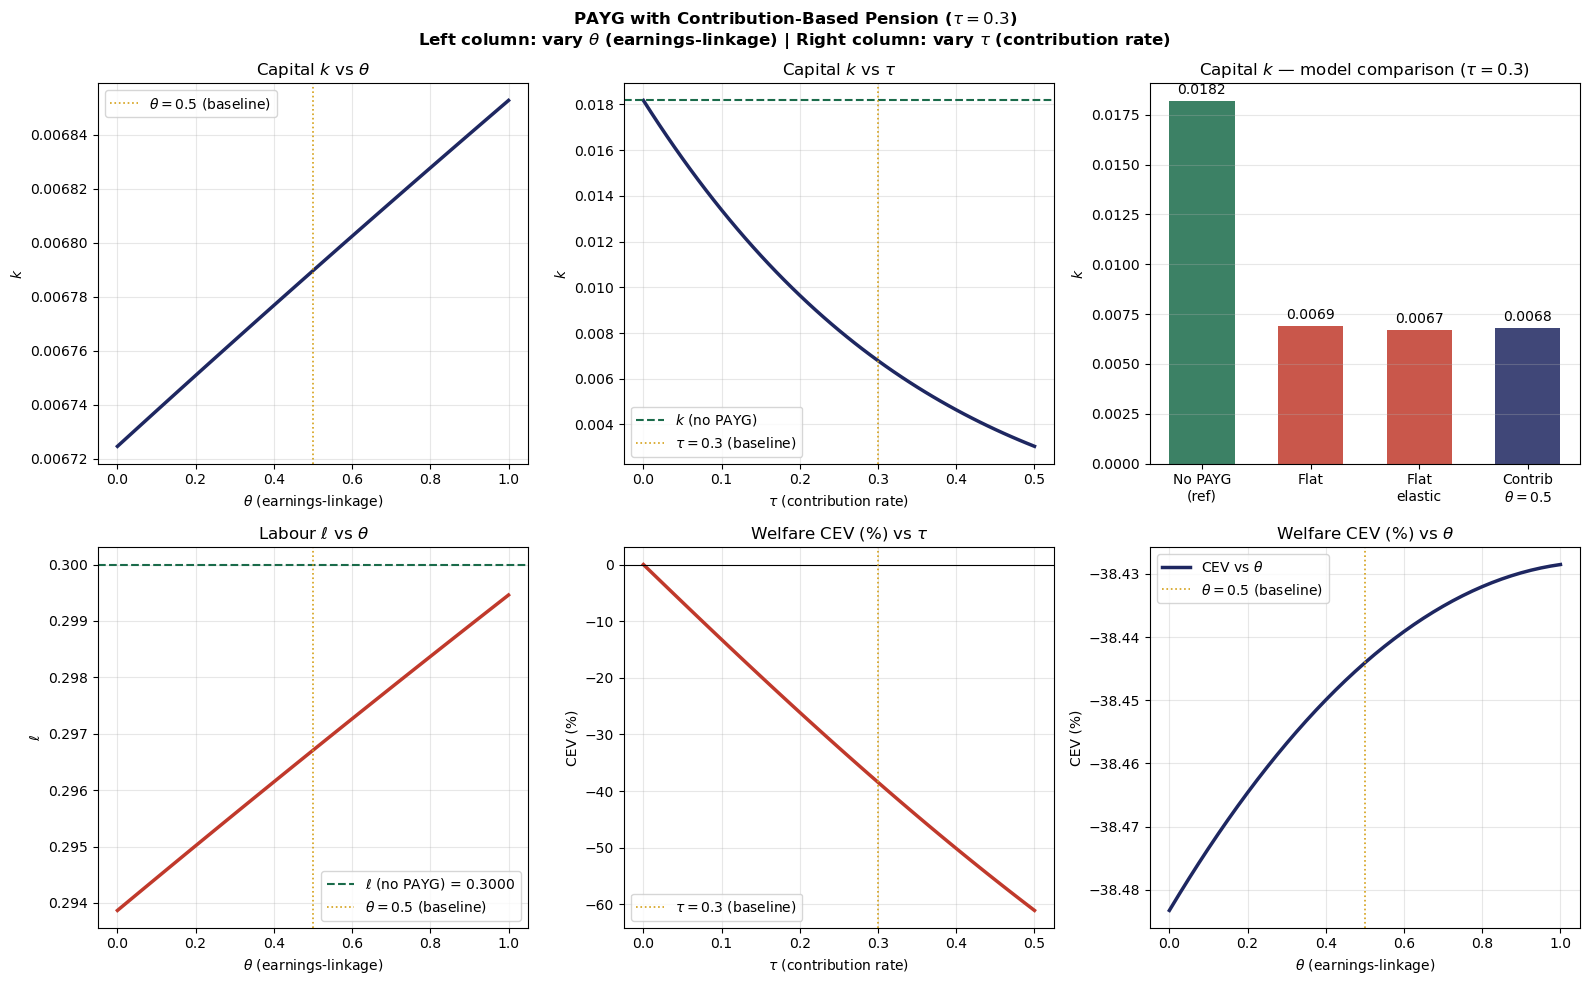

Figures done.


In [74]:
NAVY  = '#1E2761'
RED   = '#C0392B'
GREEN = '#1A6B4A'
AMBER = '#D4A017'
STEEL = '#2E75B6'

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'PAYG with Contribution-Based Pension ($\\tau=0.3$)\n'
    'Left column: vary $\\theta$ (earnings-linkage) | '
    'Right column: vary $\\tau$ (contribution rate)',
    fontsize=12, fontweight='bold')

# ── Extract sweep arrays ─────────────────────────────────────────────────
k_th  = [s['k']  for s in res_theta]
l_th  = [s['l']  for s in res_theta]
y_th  = [s['y']  for s in res_theta]
cev_th = [cev(s['U'])*100 for s in res_theta]
pen_th = [s['pen'] for s in res_theta]

k_ta  = [s['k']  for s in res_tau]
l_ta  = [s['l']  for s in res_tau]
y_ta  = [s['y']  for s in res_tau]
cev_ta = [cev(s['U'])*100 for s in res_tau]
pen_ta = [s['pen'] for s in res_tau]

# ── Row 0: Capital ───────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(thetas, k_th, color=NAVY, lw=2.5)
#ax.axhline(ss_ref['k'], color=GREEN, lw=1.5, ls='--',
#           label=f'$k$ (no PAYG) = {ss_ref["k"]:.4f}')
ax.axvline(theta_base, color=AMBER, lw=1.2, ls=':',
           label=f'$\\theta={theta_base}$ (baseline)')
ax.set_title('Capital $k$ vs $\\theta$')
ax.set_xlabel('$\\theta$ (earnings-linkage)')
ax.set_ylabel('$k$'); ax.legend(fontsize=10); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(taus, k_ta, color=NAVY, lw=2.5)
ax.axhline(ss_ref['k'], color=GREEN, lw=1.5, ls='--',
           label=f'$k$ (no PAYG)')
ax.axvline(tau_base, color=AMBER, lw=1.2, ls=':',
           label=f'$\\tau={tau_base}$ (baseline)')
ax.set_title('Capital $k$ vs $\\tau$')
ax.set_xlabel('$\\tau$ (contribution rate)')
ax.set_ylabel('$k$'); ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── Inset comparison bar (right of row 0) ────────────────────────────────
ax = axes[0, 2]
models   = ['No PAYG\n(ref)', 'Flat\n', 'Flat\nelastic', 'Contrib\n$\\theta=0.5$']
k_vals   = [ss_ref['k'], ss_ine_flat['k'], ss_ela['k'], ss_base['k']]
bar_col  = [GREEN, RED, RED, NAVY]
bars = ax.bar(models, k_vals, color=bar_col, alpha=0.85, width=0.6)
for bar, v in zip(bars, k_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.0002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_title('Capital $k$ — model comparison ($\\tau=0.3$)')
ax.set_ylabel('$k$'); ax.grid(axis='y', alpha=0.3)

# ── Row 1: Labour ────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(thetas, l_th, color=RED, lw=2.5)
ax.axhline(ss_ref['l'], color=GREEN, lw=1.5, ls='--',
           label=f'$\\ell$ (no PAYG) = {ss_ref["l"]:.4f}')
ax.axvline(theta_base, color=AMBER, lw=1.2, ls=':',
           label=f'$\\theta={theta_base}$ (baseline)')
ax.set_title('Labour $\\ell$ vs $\\theta$')
ax.set_xlabel('$\\theta$ (earnings-linkage)')
ax.set_ylabel('$\\ell$'); ax.legend(fontsize=10); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(taus, cev_ta, color=RED, lw=2.5)
ax.axhline(0, color='k', lw=0.8)
ax.axvline(tau_base, color=AMBER, lw=1.2, ls=':',
           label=f'$\\tau={tau_base}$ (baseline)')
ax.set_title('Welfare CEV (%) vs $\\tau$')
ax.set_xlabel('$\\tau$ (contribution rate)')
ax.set_ylabel('CEV (%)'); ax.legend(fontsize=10); ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.plot(thetas, cev_th, color=NAVY, lw=2.5, label='CEV vs $\\theta$')
#ax.axhline(0, color='k', lw=0.8)
ax.axvline(theta_base, color=AMBER, lw=1.2, ls=':',
           label=f'$\\theta={theta_base}$ (baseline)')
#ax.fill_between(thetas, cev_th, 0,
#                where=[v<0 for v in cev_th], color=RED, alpha=0.15)
#ax.fill_between(thetas, cev_th, 0,
#                where=[v>0 for v in cev_th], color=GREEN, alpha=0.15)
ax.set_title('Welfare CEV (%) vs $\\theta$')
ax.set_xlabel('$\\theta$ (earnings-linkage)')
ax.set_ylabel('CEV (%)')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# Annotate theta* where CEV crosses zero
cev_arr = np.array(cev_th)
sign_changes = np.where(np.diff(np.sign(cev_arr)))[0]
if len(sign_changes) > 0:
    theta_star = thetas[sign_changes[0]]
    ax.axvline(theta_star, color=GREEN, lw=1.5, ls='--',
               label=f'$\\theta^*\\approx{theta_star:.2f}$ (CEV=0)')
    ax.legend(fontsize=10)

plt.tight_layout()

fig.savefig(os.path.join(output_dir, "comparison_contribution_based.png"), dpi=150, bbox_inches='tight')
plt.show()

print('Figures done.')

## Cell 9 — Economic interpretation

### Effect of earnings-linkage $\theta$ (left column)

As $\theta$ rises from 0 to 1:

- **Capital $k$ rises** toward the no-PAYG level: workers save more because
  part of the contribution now comes back as pension, reducing the
  implicit tax on saving.
- **Labour $\ell$ rises** toward the no-PAYG level: the effective labour
  tax falls because working more raises the future pension (Eq.4 RHS
  gains the term $\theta\tau w/(1+r)$).
- **Welfare CEV rises** (less negative): the PAYG system becomes less
  distortionary. At some $\theta^*$ the CEV crosses zero — beyond this
  the actuarial linkage more than compensates for the low PAYG return $n < r$.

### Effect of contribution rate $\tau$ (middle column)

As $\tau$ rises:

- **Capital falls** monotonically: more crowding-out of private saving.
- **Welfare CEV falls** monotonically: higher contribution = more distortion.

### Cross-model comparison ($\tau=0.3$)

| Model | Design | Capital loss | Welfare cost |
|---|---|---|---|
|  | Flat, inelastic $\ell$ | 62% | −38.4% |
|  | Flat, elastic $\ell$ | 63% | −38.5% |
|  | Contrib-based $\theta=0.5$, elastic | Smaller | Less negative |

The contribution-based design reduces distortions because it makes the
PAYG system behave more like a forced savings plan and less like a pure tax.